In [27]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [28]:
### toy data ###
n = 20
x = np.linspace(0,20,n)
y = 3 * x - 2 + np.random.normal(0,1,n)

X_train,X_test,y_train,y_test = train_test_split(x.reshape(-1,1),y, test_size=0.2,random_state=123)

In [ ]:
def get_grb_fitted(X_train=X_train, y_train=y_train, alphas=[0.025,0.5,0.975]):
    
    pred_list=[]
    for alpha in alphas:
        grb = GradientBoostingRegressor(loss="quantile",alpha=alpha).fit(X_train,y_train)
        pred= grb.predict(X_train)
        pred_list.append(pred)

    pred_df = pl.DataFrame(pred_list)
    pred_df.columns=["lci","median","uci"]   
    
    return pred_df


In [ ]:
grb_fitted = get_grb_fitted()
grb_fitted

lci,median,uci
f64,f64,f64
2.994472,23.720914,54.232524
2.994472,19.131064,54.232524
2.994472,54.22262,58.050493
2.994472,36.646053,54.232524
-1.447457,-1.445568,54.232524
…,…,…
2.994472,2.922287,54.232524
2.994472,16.535017,54.232524
2.994472,54.22262,54.232524


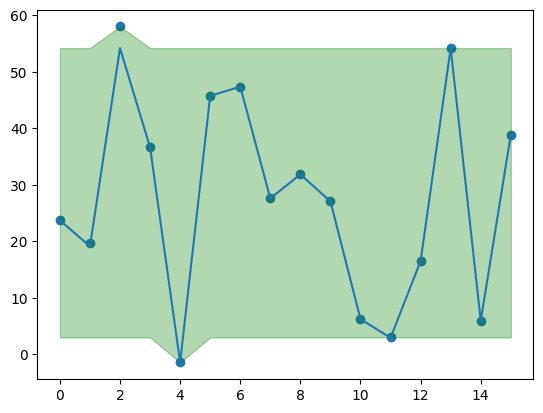

In [ ]:
plt.scatter(np.arange(len(y_train)),y_train)
plt.plot(grb_fitted["median"])
plt.fill_between(np.arange(len(y_train)),grb_fitted["lci"],grb_fitted["uci"],color="green",alpha=0.3)


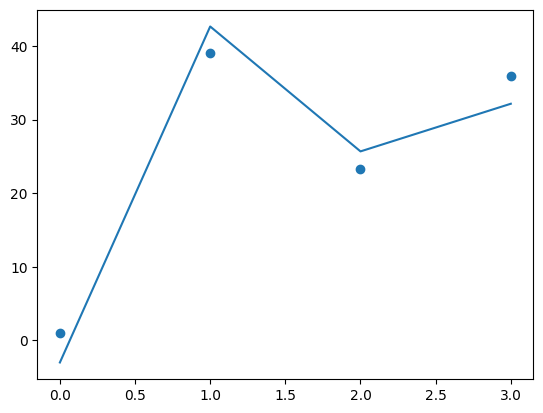

In [ ]:
y_pred = grb.predict(X_test)
y_pred

plt.scatter(np.arange(len(y_test)),y_test)
plt.plot(y_pred)

In [18]:
# linear regression #
def get_lm_pred(X_train=X_train, X_test=X_test, y_train=y_train, alpha=0.05):
    lr = sm.OLS(y_train, sm.add_constant(X_train)).fit()

    y_pred = lr.get_prediction(sm.add_constant(X_test)).summary_frame(alpha=alpha)

    pred_mean = y_pred["mean"]
    pred_lci = y_pred["obs_ci_lower"]
    pred_uci = y_pred["obs_ci_upper"]

    pred_df = pl.DataFrame({"pred": pred_mean, "lci": pred_lci, "uci": pred_uci})

    return pred_df

In [ ]:
def get_grb_pred(X_train=X_train, X_test=X_test, y_train=y_train, alphas=[0.025,0.5,0.975]):
    
    pred_list=[]
    for alpha in alphas:
        grb = GradientBoostingRegressor(loss="quantile",alpha=alpha).fit(X_train,y_train)
        pred= grb.predict(X_test)
        pred_list.append(pred)

    pred_df = pl.DataFrame(pred_list)
    pred_df.columns=["lci","median","uci"]   
    
    return pred_df
    

In [ ]:
lm_df = get_lm_pred()
grb_df = get_grb_pred()

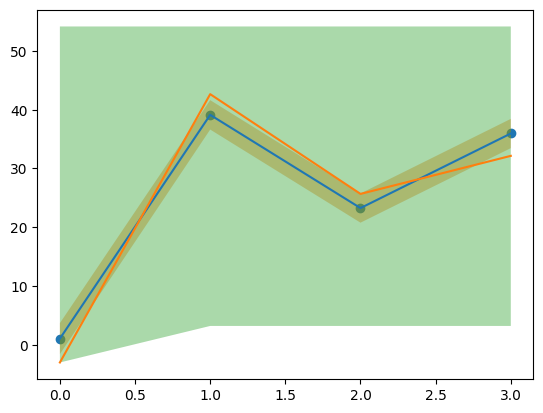

In [ ]:
x_coords = np.arange(len(y_test))

plt.scatter(x_coords,y_test)
plt.plot(lm_df["pred"])
plt.fill_between(x_coords, lm_df["lci"],lm_df["uci"],alpha = 0.4)

plt.plot(grb_df["median"])
plt.fill_between(x_coords, grb_df["lci"],grb_df["uci"],alpha = 0.4)


In [ ]:
grb_df

lci,median,uci
f64,f64,f64
-2.98722,-2.984776,54.150706
3.226047,42.641436,54.150706
3.226047,25.679117,54.150706
3.226047,32.149313,54.150706
